toca sdacatrle el promedio a cada coeficiente y su varianza cada una en un vector y luego concatenar esos vectores y hacer una matriz por el numAudios x 72(36p y 36 DE)

otra matriz con la caracterizacion de cada audio x 19k





Procesando: 1.wav


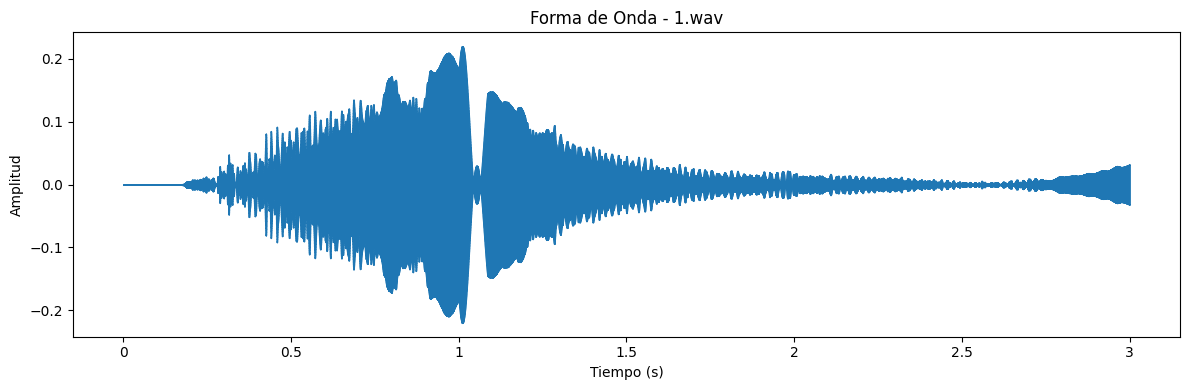

Procesando: 10.wav


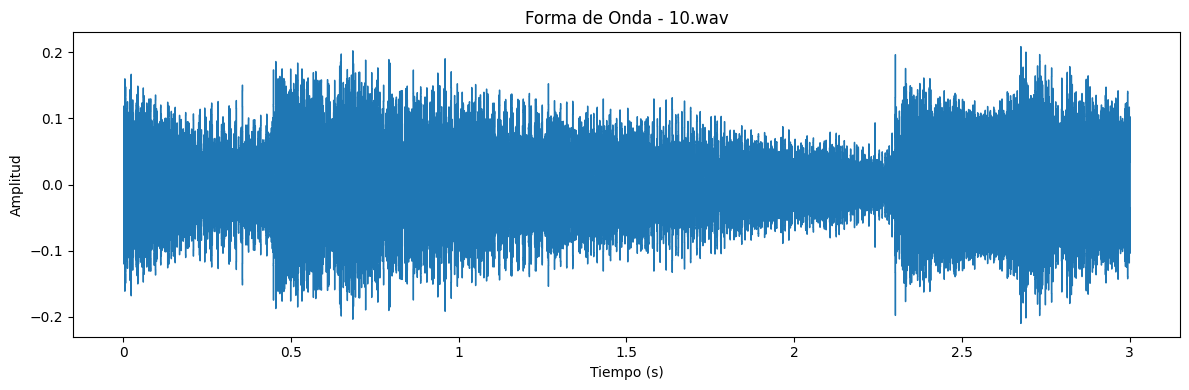

Procesando: 100.wav


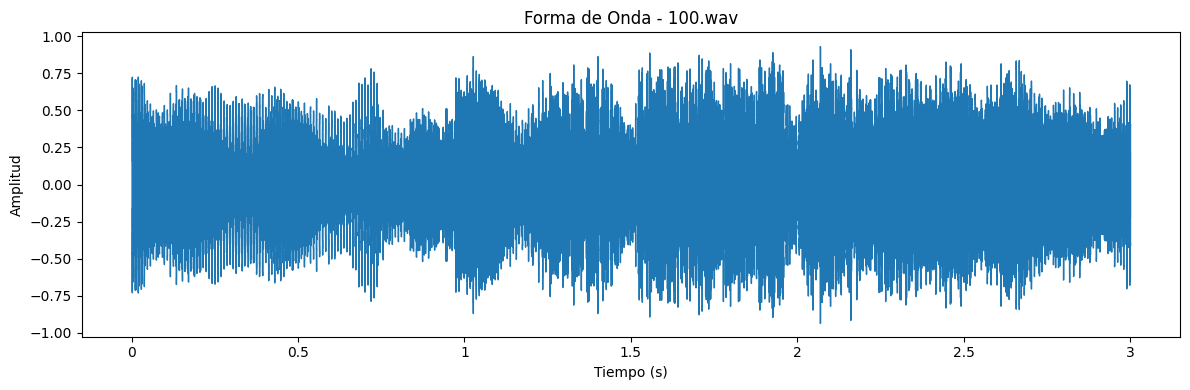

Procesando: 1000.wav


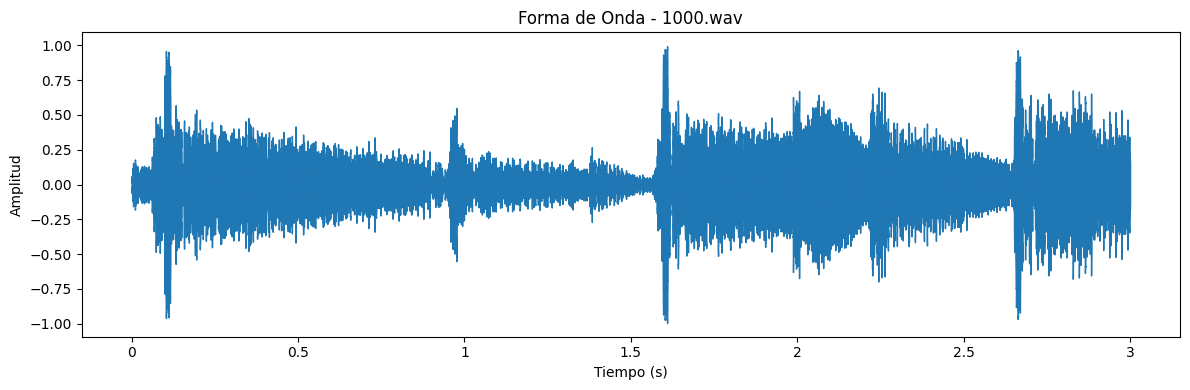

Procesando: 1001.wav


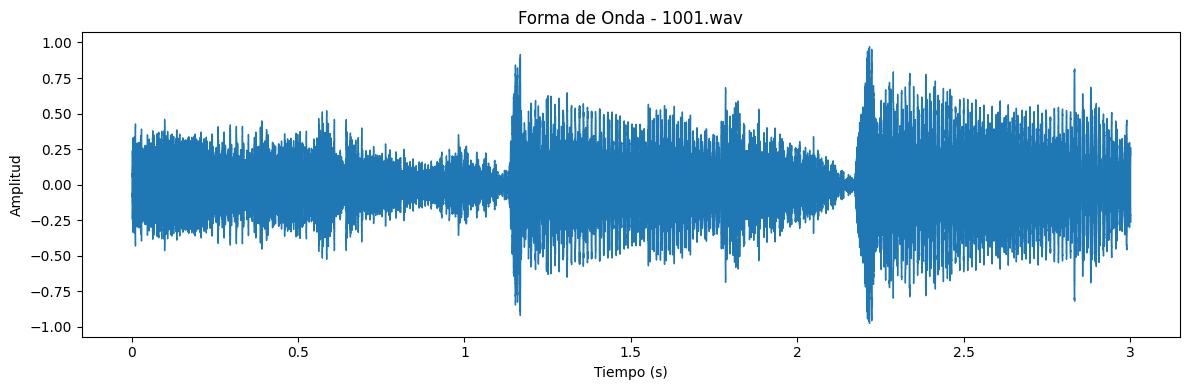

Procesando: 1002.wav


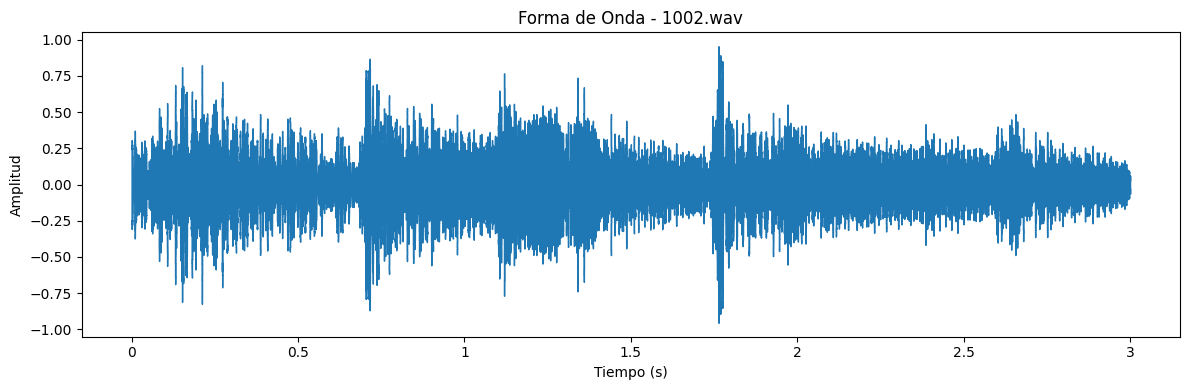

Procesando: 1003.wav


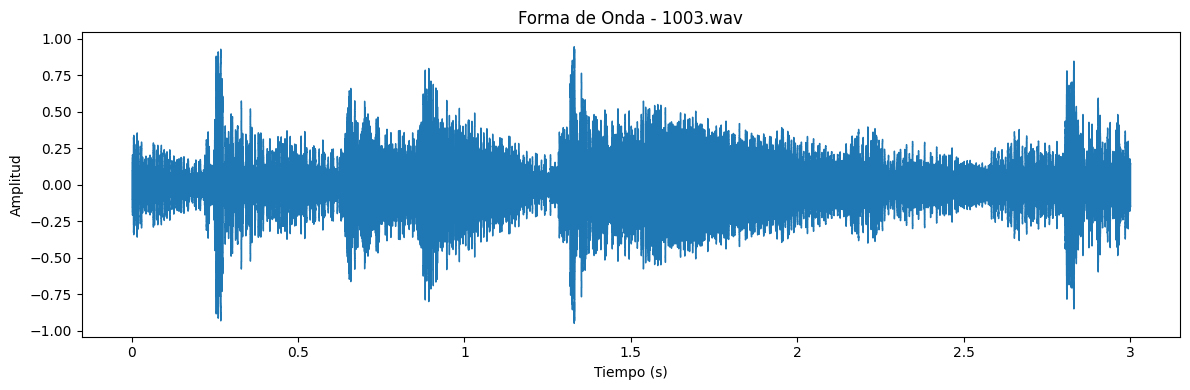

Procesando: 1004.wav


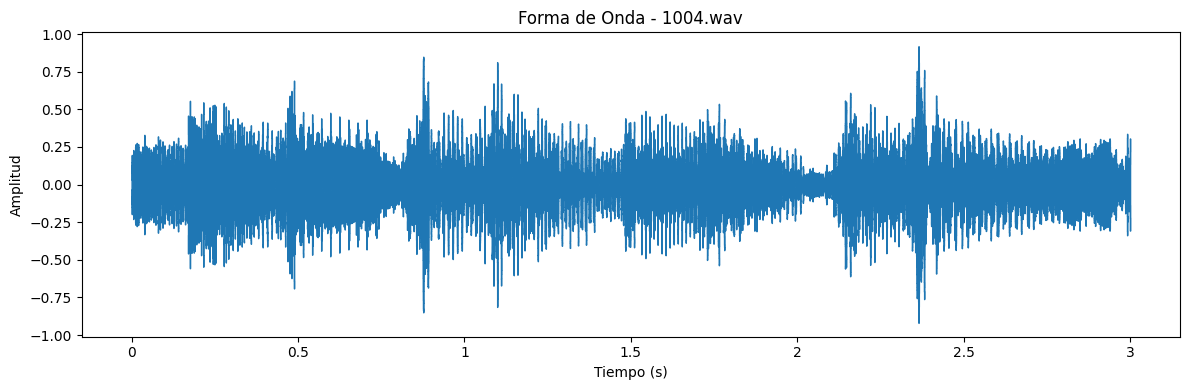

Procesando: 1005.wav


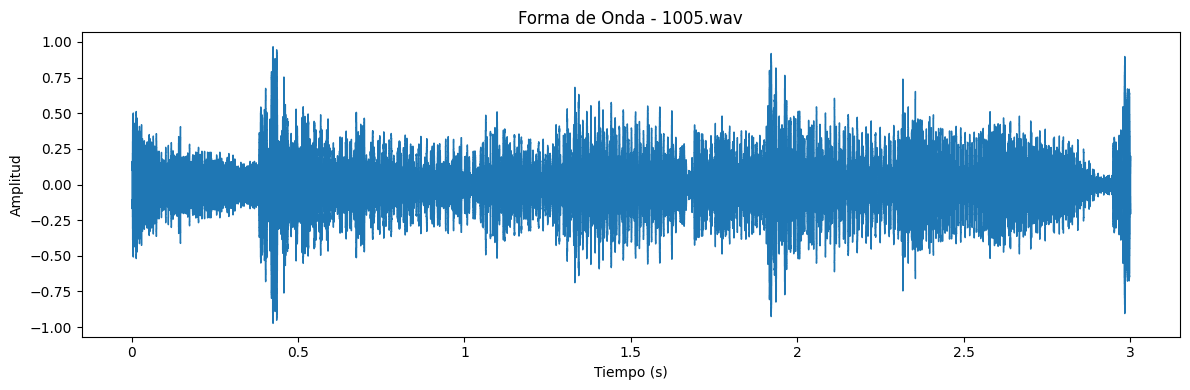

Procesando: 1006.wav


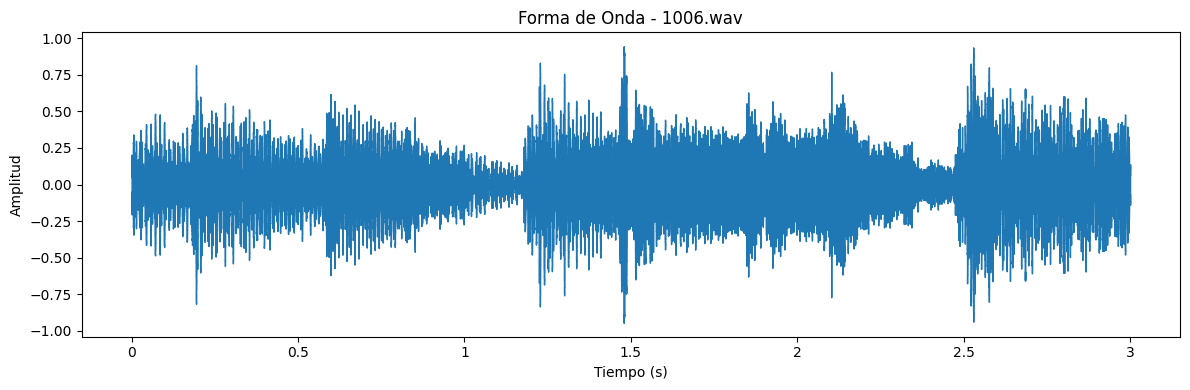

In [7]:
from pathlib import Path
import librosa
import matplotlib.pyplot as plt
import librosa.display

carpeta_audios = Path("Dataset") / "Audios" / "Guitarra"

archivos = list(carpeta_audios.glob("*.wav"))

for archivo in archivos[:10]:
    arreglo, frec_muestreo = librosa.load(archivo, sr=None)
    print("Procesando:", archivo.name)

    plt.figure(figsize=(12,4))
    librosa.display.waveshow(arreglo, sr=frec_muestreo)
    plt.title(f'Forma de Onda - {archivo.name}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.tight_layout()
    plt.show()

In [ ]:
#escucharlo:
try:
  from IPython.display import Audio
  display(Audio(data=arreglo, rate=frec_muestreo))
except Exception:
  pass

Preenfasis


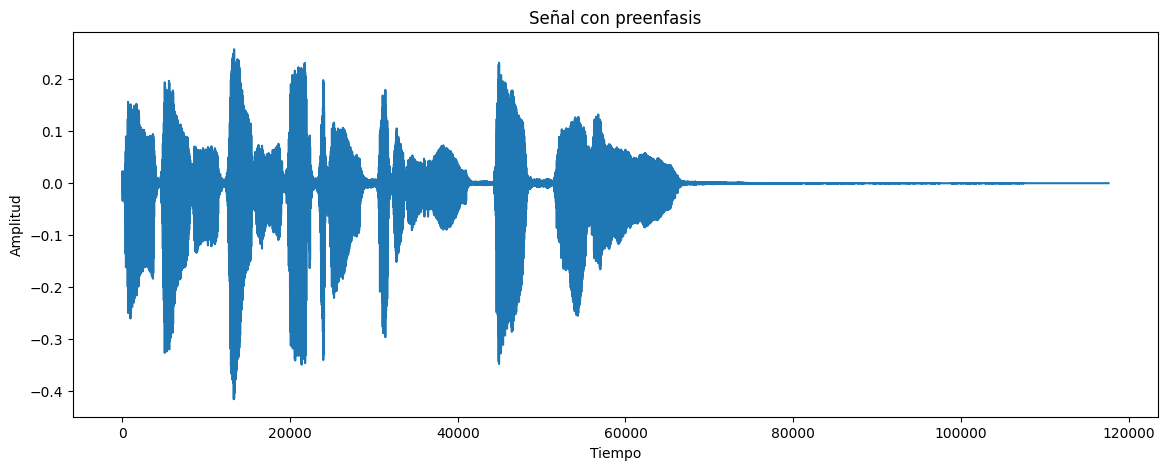

In [ ]:
import numpy as np
y = arreglo
preenfasis = 0.97
y_preenfatizada = np.append(y[0],y[1:]-preenfasis*y[:-1])

#visualizar
plt.figure(figsize=(14,5))
plt.plot(y_preenfatizada)
plt.title('Señal con preenfasis')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.tight_layout
plt.show()

Ventaneo o framming con windowing

In [ ]:
tamano_cuadro = 0.025 #25ms
paso_cuadro= 0.01 #10ms    --> para solapar(suavizar)

sr = frec_muestreo
#convertir de segundos a muestras
longitud_cuadro, paso_cuadros_muestras = tamano_cuadro*sr, paso_cuadro*sr
longitud_senal = len(y_preenfatizada)

#redondear enteros
longitud_cuadro = int(longitud_cuadro)
paso_cuadros_muestras = int(paso_cuadros_muestras)

#calcular mel numero de cuadros
num_cuadros = int(np.ceil(float(np.abs(longitud_senal-longitud_cuadro))/paso_cuadros_muestras))

#rellenar para que se asegure que todos los frames tengan el mismo numero de muestras
long_senal_rellenar = num_cuadros*paso_cuadros_muestras+longitud_cuadro
ceros_rellenar = np.zeros(long_senal_rellenar-longitud_senal)
senal_rellena = np.append(y_preenfatizada,ceros_rellenar)

#Dividir la señal en frames
indices=  np.tile(np.arange(0,longitud_cuadro),(num_cuadros,1)) + \
          np.tile(np.arange(0, num_cuadros*paso_cuadros_muestras, paso_cuadros_muestras),(longitud_cuadro,1)).T
cuadros = senal_rellena[indices.astype(np.int32, copy=False)]

print(indices)
print(len(cuadros))


[[     0      1      2 ...    548    549    550]
 [   220    221    222 ...    768    769    770]
 [   440    441    442 ...    988    989    990]
 ...
 [116600 116601 116602 ... 117148 117149 117150]
 [116820 116821 116822 ... 117368 117369 117370]
 [117040 117041 117042 ... 117588 117589 117590]]
533


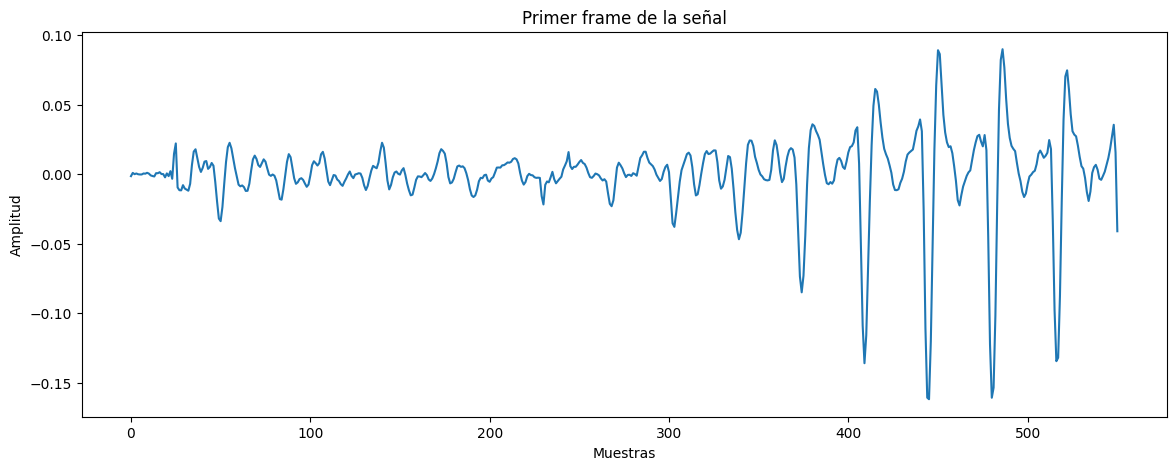

In [ ]:
#Grqaficar primer frame
plt.figure(figsize=(14,5))
plt.plot(cuadros[0])
plt.title('Primer frame de la señal')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()

APLICAR LA VENTANA DE HAMMING

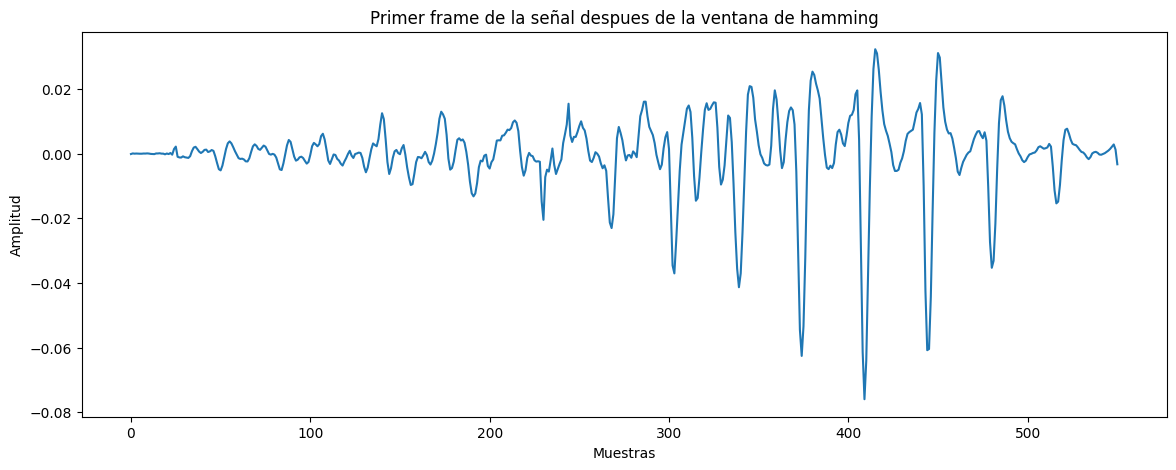

In [ ]:
cuadros *= np.hamming(longitud_cuadro)

#visualizar
plt.figure(figsize=(14,5))
plt.plot(cuadros[0])
plt.title('Primer frame de la señal despues de la ventana de hamming')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()

CLASE 17 FEBRERO CONTINUACION

(533, 512)


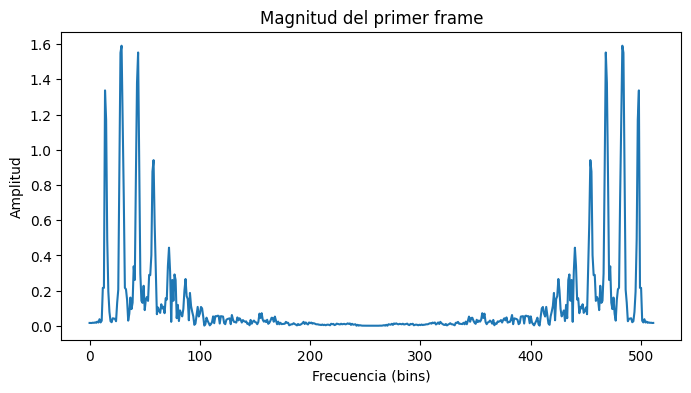

In [ ]:
#Transformada de fourier
NFFT=512 #numerto de puntos de la transformada de fourier

#calcular magnitud y el espectro de potencia
magnitud_cuadros = np.abs(np.fft.fft(cuadros,NFFT)) #magnitud
potencia_cuadros = ((1.0/NFFT)*((magnitud_cuadros)**2)) #espectro potencia

print (magnitud_cuadros.shape)

#grafico
plt.figure(figsize=(8,4))
plt.plot(magnitud_cuadros[0])
plt.title('Magnitud del primer frame')
plt.xlabel('Frecuencia (bins)')
plt.ylabel('Amplitud')
plt.show()


ESPECTOGRAMA

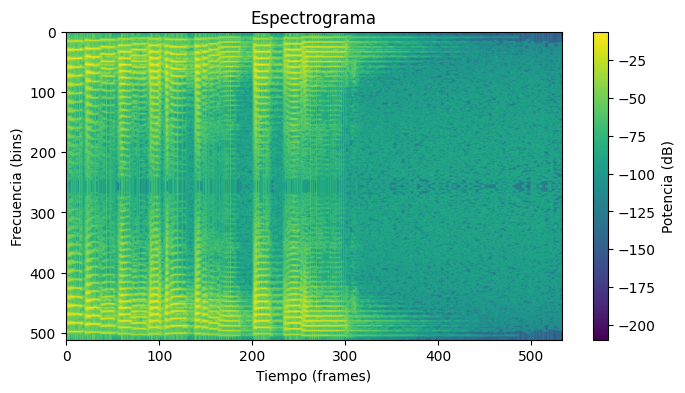

In [ ]:
plt.figure(figsize=(8,4))
plt.imshow(10*np.log10(potencia_cuadros.T),cmap='viridis',aspect='auto') #matriz traspuesta por el .T
plt.title('Espectrograma')
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(label='Potencia (dB)')
plt.show()

#el espectograma ya cuenta como un descriptor de audio

In [ ]:
#APLICACION DEL BANCO DE FILTROS MEL

#definir numero de filtros
num_filtros = 40

#limites frecuencia en escala de Mel
mel_frec_baja=0
mel_frec_alta=2595*np.log10(1+(sr/2)/700) #conversion de Hz a mEL

#Calcular puntos igualmente espaciados en la escala de Mel
puntos_mel = np.linspace(mel_frec_baja, mel_frec_alta, num_filtros+2)

#convertir Mel a Haz
puntos_hz = (700*(10**(puntos_mel/2595)-1))

#calcular los bins de frecuencia para la FFT
bins = np.floor((NFFT+1)*puntos_hz/sr)
bins = bins.astype(int)


#inicializar la matriz del banco de filtros
banco_filtros = np.zeros((num_filtros, int(np.floor(NFFT))))

#construir los filtros triangulares Mel
for m in range(1, num_filtros+1):
  f_m_menos = int(bins[m-1]) #limite izquierdo
  f_m = int(bins[m]) #centro
  f_m_mas = int(bins[m+1]) #limite derecho

  #pendiente4 ascendente
  for k in range(f_m_menos, f_m):
    banco_filtros[m-1,k] = (k-bins[m-1])/(bins[m]-bins[m-1])

  #pendiente4 descendente
  for k in range(f_m, f_m_mas):
    banco_filtros[m-1,k] = (bins[m+1]-k)/(bins[m+1]-bins[m])

#Aplicar los filtros a la potencia de los frames
energia_filtros = np.dot(potencia_cuadros, banco_filtros.T)

#para evitar log de cero 0 --> coloca valores muy pequeños cercanos a 0 pero no es 0
energia_filtros = np.where(energia_filtros == 0, np.finfo(float).eps, energia_filtros)

#convertir a escala logaritmica
energia_filtros = 20*np.log10(energia_filtros)

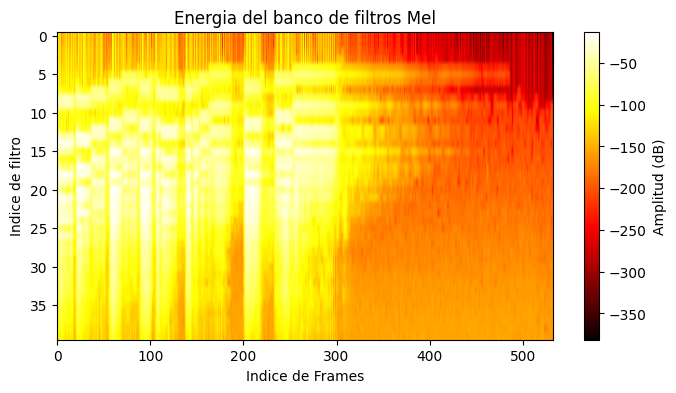

In [ ]:
#graficar la energia del banco de filtros
plt.figure(figsize=(8,4))
plt.imshow(energia_filtros.T, cmap='hot', aspect = 'auto')
plt.title('Energia del banco de filtros Mel')
plt.xlabel('Indice de Frames')
plt.ylabel('Indice de filtro')
plt.colorbar(label='Amplitud (dB)')
plt.show()


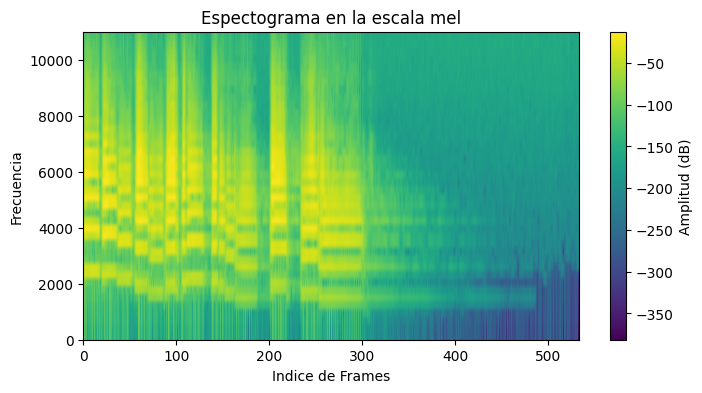

In [ ]:
#Espectograma en la escala mel
plt.figure(figsize=(8,4))
plt.imshow(energia_filtros.T,aspect = 'auto', origin='lower', extent=[0, len(energia_filtros), puntos_hz[0], puntos_hz[-1]])
plt.title('Espectograma en la escala mel')
plt.xlabel('Indice de Frames')
plt.ylabel('Frecuencia')
plt.colorbar(label='Amplitud (dB)')
plt.show()

TRANSFORMADA DISCRETA DEL COSENO (DCT)


In [ ]:
#Calcular transformada diuscreta del coseno

from scipy.fftpack import dct

#numero de coeficientes cepstrales a calcular
num_ceps = 12

mfcc = dct(energia_filtros, type=2, axis=1, norm='ortho')[:, :num_ceps]

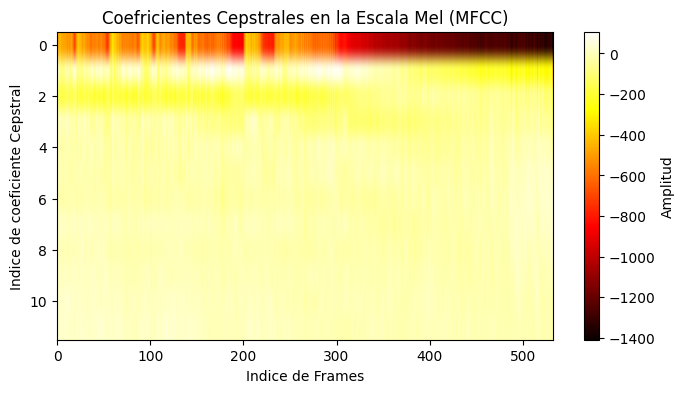

In [ ]:
#Espectograma en la escala mel
plt.figure(figsize=(8,4))
plt.imshow(mfcc.T, cmap='hot', aspect='auto')
plt.title('Coefricientes Cepstrales en la Escala Mel (MFCC)')
plt.xlabel('Indice de Frames')
plt.ylabel('Indice de coeficiente Cepstral')
plt.colorbar(label='Amplitud')
plt.show()

In [ ]:
#Deltas (primera derivada)
delta_mfcc = librosa.feature.delta(mfcc, order=1, width=9)
#Deltas-deltas(segunda derivada)
delta2_mfcc = librosa.feature.delta(mfcc, order=2, width=9)

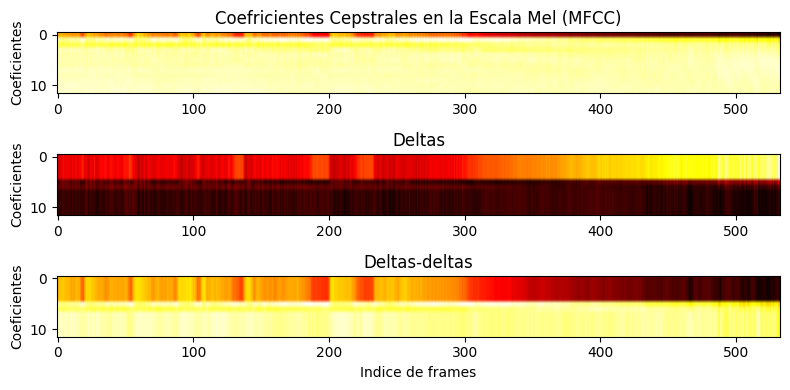

In [ ]:
#Espectograma en la escala mel
plt.figure(figsize=(8,4))
plt.subplot(3,1,1)
plt.imshow(mfcc.T, cmap='hot', aspect='auto')
plt.title('Coefricientes Cepstrales en la Escala Mel (MFCC)')
plt.ylabel('Coeficientes')

plt.subplot(3,1,2)
plt.imshow(delta_mfcc.T, cmap='hot', aspect='auto')
plt.title('Deltas')
plt.ylabel('Coeficientes')

plt.subplot(3,1,3)
plt.imshow(delta2_mfcc.T, cmap='hot', aspect='auto')
plt.title('Deltas-deltas')
plt.xlabel('Indice de frames')
plt.ylabel('Coeficientes')
plt.tight_layout()
plt.show()

In [ ]:
#Vector de caracteristicas

caracteristicas = np.concatenate((mfcc, delta_mfcc, delta2_mfcc), axis=1)
print(caracteristicas.shape)

(533, 36)


In [ ]:
#Normalizar cepstrales  (CMVN)
carac_norm = (caracteristicas - np.mean(caracteristicas, axis=0))/np.std(caracteristicas, axis=0)
print(caracteristicas[0])
print(carac_norm [0])

[-5.36701948e+02 -6.67011228e+00 -1.31968517e+02 -2.71620654e+01
 -1.40777419e+01 -1.16161653e+01 -1.61725337e+01  4.37961119e+00
 -3.21855167e-03  2.11080517e+01  2.23388979e+01  1.47453106e+01
  4.04513659e+01  4.04513659e+01  4.04513659e+01  4.04513659e+01
  4.04513659e+01  9.46661854e+00  1.34364139e+01  5.97495287e+00
  5.97495287e+00  5.97495287e+00  5.97495287e+00  5.97495287e+00
 -2.79607468e+01 -2.79607468e+01 -2.79607468e+01 -2.79607468e+01
 -2.79607468e+01  8.85925930e-01 -5.52573085e+00 -3.86105131e-01
 -3.86105131e-01 -3.86105131e-01 -3.86105131e-01 -3.86105131e-01]
[ 0.91042477  0.47720055 -0.11143041  0.8382946   0.49911222  0.35270082
  0.30823595  0.77364647  1.11708665  2.39165503  1.84550966  0.85084411
 -0.84319394 -0.84319394 -0.84319394 -0.84319394 -0.84319394 -0.16690767
  0.47203402  0.14034519  0.14034519  0.14034519  0.14034519  0.14034519
  0.83870893  0.83870893  0.83870893  0.83870893  0.83870893  0.47871103
  0.1502343   0.46538285  0.46538285  0.46538285 